# 📊 Dataset Information

**Note:** The dataset for this project is **not included in this repository** to keep the repository lightweight.  

You can download the dataset from **Kaggle** using the link below:  

[Download The Synthetic Loan Approval Dataset](https://www.kaggle.com/datasets/dharmendrapandit12/synthetic-bank-loan-approval-dataset-20k-records)  

Please make sure to place the downloaded CSV file in the same directory as this notebook before running any code.

# Importing

## Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay

/kaggle/input/datasets/dharmendrapandit12/synthetic-bank-loan-approval-dataset-20k-records/synthetic_loan_approval_dataset.csv


## Import CSV And convert to DataFrame

In [2]:
df = pd.read_csv('synthetic_loan_approval_dataset.csv')

# Preprocessing

## Frist five row

In [3]:
pd.set_option('display.max_columns', None)
df.head()

,Application_ID,Age,Gender,Marital_Status,Education,Dependents,Residence_Type,City_Tier,Employment_Type,Years_at_Current_Job,Total_Work_Experience,Monthly_Income,Annual_Income,Other_Income,Existing_Loans,Existing_Loan_Amount,Monthly_EMI,Debt_to_Income,Savings,Investments,Bank_Balance,Credit_Card_Utilization,Number_of_Bank_Accounts,Number_of_Credit_Cards,Credit_Score,Loan_Defaults,Missed_Payments,Tax_Return_Filed,PAN_Verified,Aadhaar_Verified,Loan_Purpose,Loan_Amount,Loan_Tenure,Interest_Rate,Collateral,Property_Value,Collateral_Value,Loan_to_Value,Loan_Status
0,APP100000,24,Female,Single,Graduate,0,Rural,3,Private,1,2,60328,799160,0.0,0,0,0,0.00,1162827.0,126871.0,1107114.0,25.74,3,3,716.0,0,0,Yes,Yes,Yes,Vehicle,957295,3,9.05,Yes,1375548.0,1160384.0,82.50,Approved
1,APP100001,26,Male,Married,Graduate,2,Urban,1,Private,0,4,50161,607602,0.0,1,380423,5146,10.26,494394.0,110486.0,224539.0,31.53,3,1,622.0,0,0,Yes,Yes,Yes,Home,3245374,30,12.74,Yes,5953437.0,5209406.0,62.30,Approved
2,APP100002,58,Female,Married,Post Graduate,1,Urban,1,Government,21,33,189244,2375961,0.0,2,12237646,136268,72.01,1475373.0,0.0,812703.0,1.98,4,4,585.0,0,1,Yes,Yes,Yes,Home,13847512,25,14.36,Yes,19901144.0,17072665.0,81.11,Rejected
3,APP100003,38,Others,Married,Graduate,1,Rural,4,Private,2,8,35947,468925,0.0,0,0,0,0.00,171512.0,0.0,87996.0,26.43,1,1,762.0,1,0,No,Yes,Yes,Medical,277514,3,8.61,No,NaN,NaN,NaN,Approved
4,APP100004,32,Female,Single,PhD,0,Rural,4,Government,1,5,59807,766432,0.0,3,2664833,30435,50.89,206550.0,144120.0,193930.0,79.08,3,1,539.0,0,2,Yes,Yes,Yes,Home,1899085,20,14.23,Yes,2569014.0,2537834.0,74.83,Rejected


## last Five row

In [4]:
df.tail()

,Application_ID,Age,Gender,Marital_Status,Education,Dependents,Residence_Type,City_Tier,Employment_Type,Years_at_Current_Job,Total_Work_Experience,Monthly_Income,Annual_Income,Other_Income,Existing_Loans,Existing_Loan_Amount,Monthly_EMI,Debt_to_Income,Savings,Investments,Bank_Balance,Credit_Card_Utilization,Number_of_Bank_Accounts,Number_of_Credit_Cards,Credit_Score,Loan_Defaults,Missed_Payments,Tax_Return_Filed,PAN_Verified,Aadhaar_Verified,Loan_Purpose,Loan_Amount,Loan_Tenure,Interest_Rate,Collateral,Property_Value,Collateral_Value,Loan_to_Value,Loan_Status
19995,APP119995,24,Female,Single,High School,0,Urban,1,Unemployed,0,0,600,7942,0.0,0,0,0,0.00,5009.0,766.0,6177.0,38.860000,1,0,694.0,0,0,No,Yes,Yes,Home,43886,25,10.83,Yes,85168.0,69276.0,63.35,Rejected
19996,APP119996,26,Male,Single,No Formal,0,Urban,2,Skilled Labor,5,5,37696,468571,208139.0,0,0,0,0.00,208518.0,0.0,203241.0,98.987842,1,1,656.0,0,0,No,Yes,Yes,Personal,490289,3,11.04,Yes,847536.0,803485.0,61.02,Approved
19997,APP119997,36,Male,Married,Graduate,1,Urban,2,Self-Employed,7,12,103983,1326652,348057.0,1,1871712,14245,13.70,2074086.0,271231.0,1227816.0,27.750000,3,2,671.0,0,0,Yes,Yes,Yes,Home,5313640,20,10.85,Yes,8130697.0,7758031.0,68.49,Approved
19998,APP119998,27,Male,Divorced,No Formal,3,Urban,1,Unemployed,2,4,15405,204456,13573.0,0,0,0,0.00,77774.0,0.0,41660.0,50.060000,1,0,682.0,0,0,Yes,Yes,Yes,Vehicle,70215,3,10.66,Yes,96227.0,80756.0,86.95,Rejected
19999,APP119999,39,Male,Married,Graduate,1,Urban,1,Private,0,0,76985,933121,0.0,1,2013486,17681,22.97,695036.0,177479.0,728080.0,57.560000,2,1,629.0,0,1,No,Yes,Yes,Home,2717987,20,11.55,Yes,5102413.0,4559935.0,59.61,Rejected


## Shape of our dataset

In [5]:
df.shape

(20000, 39)

## List out all columns

In [6]:
df.columns

Index(['Application_ID', 'Age', 'Gender', 'Marital_Status', 'Education',
       'Dependents', 'Residence_Type', 'City_Tier', 'Employment_Type',
       'Years_at_Current_Job', 'Total_Work_Experience', 'Monthly_Income',
       'Annual_Income', 'Other_Income', 'Existing_Loans',
       'Existing_Loan_Amount', 'Monthly_EMI', 'Debt_to_Income', 'Savings',
       'Investments', 'Bank_Balance', 'Credit_Card_Utilization',
       'Number_of_Bank_Accounts', 'Number_of_Credit_Cards', 'Credit_Score',
       'Loan_Defaults', 'Missed_Payments', 'Tax_Return_Filed', 'PAN_Verified',
       'Aadhaar_Verified', 'Loan_Purpose', 'Loan_Amount', 'Loan_Tenure',
       'Interest_Rate', 'Collateral', 'Property_Value', 'Collateral_Value',
       'Loan_to_Value', 'Loan_Status'],
      dtype='object')

## Datatype of each columns

In [7]:
df.dtypes

Application_ID              object
Age                          int64
Gender                      object
Marital_Status              object
Education                   object
Dependents                   int64
Residence_Type              object
City_Tier                    int64
Employment_Type             object
Years_at_Current_Job         int64
Total_Work_Experience        int64
Monthly_Income               int64
Annual_Income                int64
Other_Income               float64
Existing_Loans               int64
Existing_Loan_Amount         int64
Monthly_EMI                  int64
Debt_to_Income             float64
Savings                    float64
Investments                float64
Bank_Balance               float64
Credit_Card_Utilization    float64
Number_of_Bank_Accounts      int64
Number_of_Credit_Cards       int64
Credit_Score               float64
Loan_Defaults                int64
Missed_Payments              int64
Tax_Return_Filed            object
PAN_Verified        

## Information of all Columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 39 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Application_ID           20000 non-null  object 
 1   Age                      20000 non-null  int64  
 2   Gender                   20000 non-null  object 
 3   Marital_Status           20000 non-null  object 
 4   Education                20000 non-null  object 
 5   Dependents               20000 non-null  int64  
 6   Residence_Type           20000 non-null  object 
 7   City_Tier                20000 non-null  int64  
 8   Employment_Type          20000 non-null  object 
 9   Years_at_Current_Job     20000 non-null  int64  
 10  Total_Work_Experience    20000 non-null  int64  
 11  Monthly_Income           20000 non-null  int64  
 12  Annual_Income            20000 non-null  int64  
 13  Other_Income             19587 non-null  float64
 14  Existing_Loans        

## Check Null Value

In [9]:
df.isnull().sum()

Application_ID                0
Age                           0
Gender                        0
Marital_Status                0
Education                     0
Dependents                    0
Residence_Type                0
City_Tier                     0
Employment_Type               0
Years_at_Current_Job          0
Total_Work_Experience         0
Monthly_Income                0
Annual_Income                 0
Other_Income                413
Existing_Loans                0
Existing_Loan_Amount          0
Monthly_EMI                   0
Debt_to_Income                0
Savings                       0
Investments                 409
Bank_Balance                193
Credit_Card_Utilization       0
Number_of_Bank_Accounts       0
Number_of_Credit_Cards        0
Credit_Score                118
Loan_Defaults                 0
Missed_Payments               0
Tax_Return_Filed            175
PAN_Verified                  0
Aadhaar_Verified              0
Loan_Purpose                  0
Loan_Amo

## Drop Null Features

In [10]:
df.drop(columns=['Loan_to_Value', 'Collateral_Value', 'Property_Value', 'Interest_Rate', 'Tax_Return_Filed', 'Credit_Score', 'Bank_Balance', 'Investments', 'Other_Income'], inplace=True)

## Check Dupicate Value

In [11]:
df.duplicated().sum()

np.int64(0)

## Summary

In [12]:
df.describe()

,Age,Dependents,City_Tier,Years_at_Current_Job,Total_Work_Experience,Monthly_Income,Annual_Income,Existing_Loans,Existing_Loan_Amount,Monthly_EMI,Debt_to_Income,Savings,Credit_Card_Utilization,Number_of_Bank_Accounts,Number_of_Credit_Cards,Loan_Defaults,Missed_Payments,Loan_Amount,Loan_Tenure
count,20000.00000,20000.000000,20000.000000,20000.000000,20000.00000,2.000000e+04,2.000000e+04,20000.000000,2.000000e+04,20000.000000,20000.000000,2.000000e+04,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,2.000000e+04,20000.000000
mean,37.41830,1.027050,1.984550,4.137700,8.25235,7.423027e+04,9.432037e+05,0.816400,1.539495e+06,18030.408400,24.915431,7.913990e+05,38.870828,2.357350,1.725500,0.124200,0.782200,1.991478e+06,11.206900
std,10.17145,1.055402,1.075207,5.231081,7.76794,4.312531e+04,5.341420e+05,0.899017,2.163698e+06,25832.897511,28.797169,7.115239e+05,21.202171,1.041156,0.944931,0.329818,1.301902,2.211235e+06,8.967576
min,21.00000,0.000000,1.000000,0.000000,0.00000,1.880000e+02,2.322000e+03,0.000000,0.000000e+00,0.000000,0.000000,7.130000e+02,0.000000,1.000000,0.000000,0.000000,0.000000,2.483000e+03,2.000000
25%,29.00000,0.000000,1.000000,0.000000,2.00000,5.023475e+04,6.365665e+05,0.000000,0.000000e+00,0.000000,0.000000,3.153700e+05,23.987500,2.000000,1.000000,0.000000,0.000000,5.308125e+05,5.000000
50%,36.00000,1.000000,2.000000,2.000000,6.00000,6.987450e+04,8.875565e+05,1.000000,6.290675e+05,7367.000000,13.350000,6.286595e+05,37.780000,2.000000,2.000000,0.000000,0.000000,1.202168e+06,7.000000
75%,44.00000,2.000000,3.000000,6.000000,12.00000,9.177900e+04,1.165836e+06,1.000000,2.550830e+06,29621.500000,46.240000,1.082626e+06,51.832500,3.000000,2.000000,0.000000,1.000000,2.909916e+06,20.000000
max,65.00000,3.000000,4.000000,42.000000,44.00000,1.311570e+06,1.573884e+07,4.000000,5.366697e+07,609363.000000,95.000000,1.895441e+07,98.987842,5.000000,5.000000,1.000000,5.000000,6.649930e+07,30.000000


# EDA

In [13]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

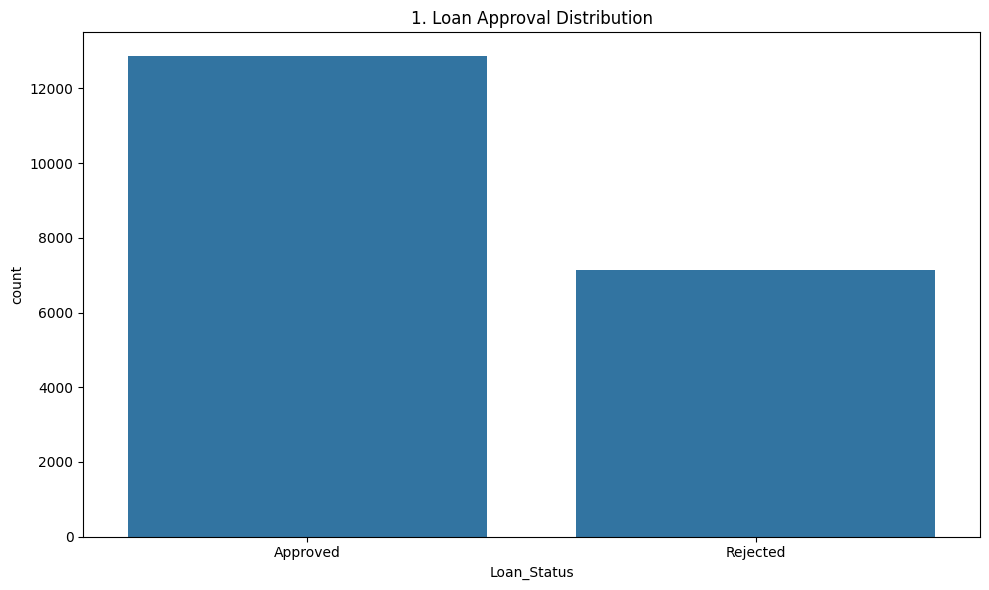

In [14]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Loan_Status')
plt.title(f'{plot_no}. Loan Approval Distribution')
show_fig()
plot_no += 1

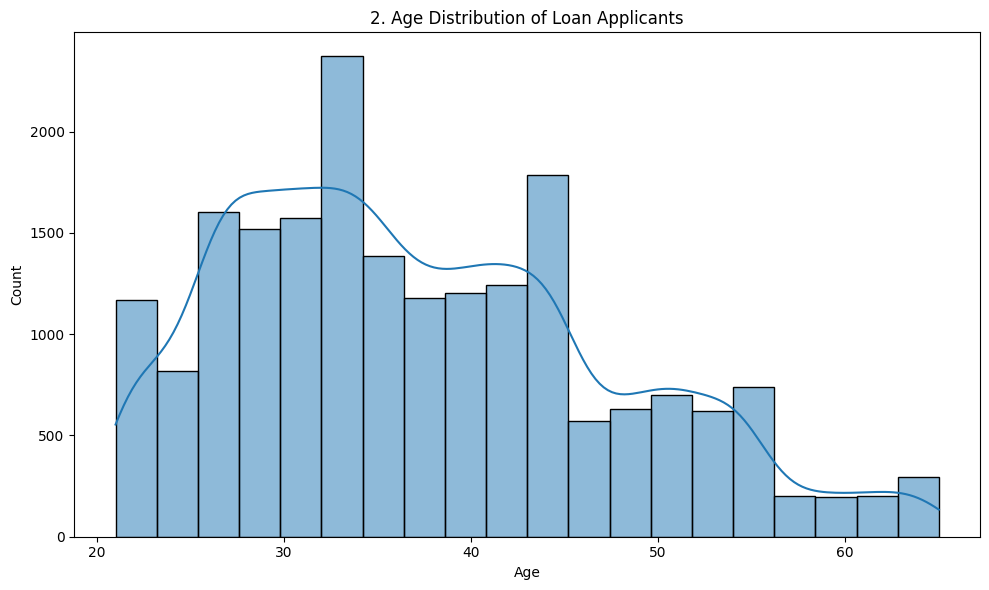

In [15]:
fig = plt.figure(figsize=(10,6))
sns.histplot(data=df, x='Age', bins=20, kde=True)
plt.title(f'{plot_no}. Age Distribution of Loan Applicants')
show_fig()
plot_no += 1

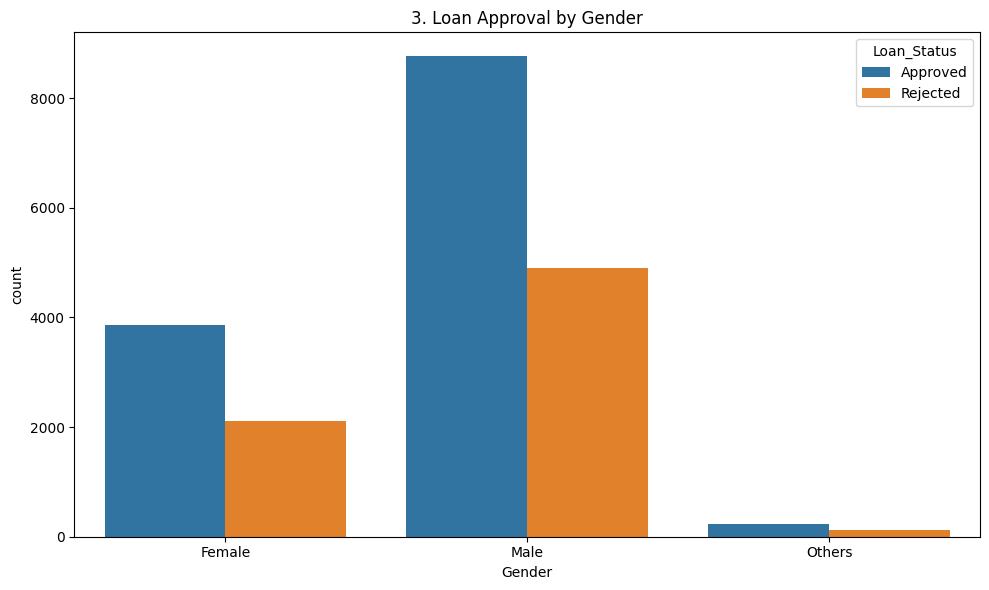

In [16]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Gender', hue='Loan_Status')
plt.title(f'{plot_no}. Loan Approval by Gender')
show_fig()
plot_no += 1

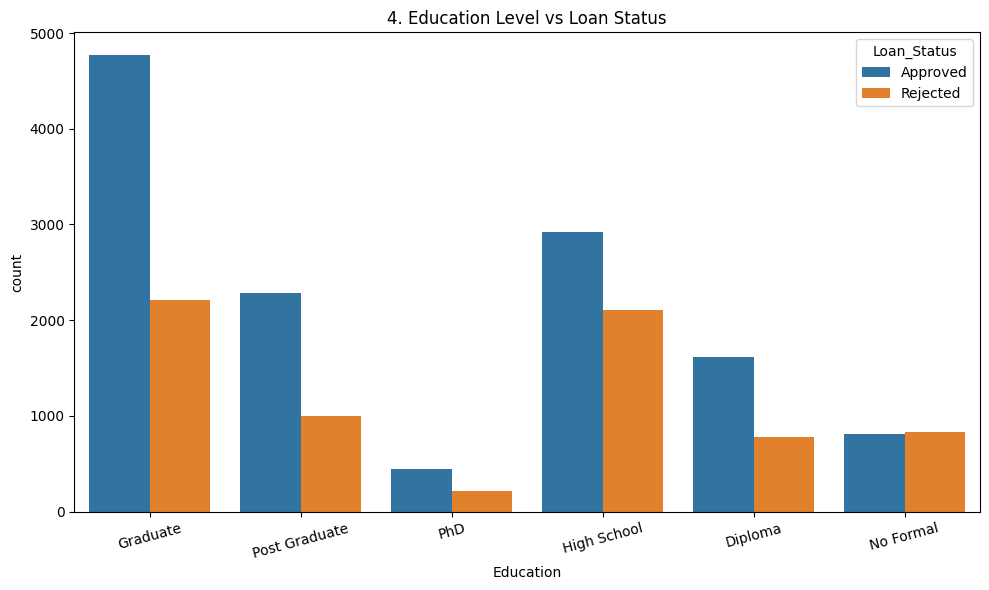

In [17]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Education', hue='Loan_Status')
plt.xticks(rotation=15)
plt.title(f'{plot_no}. Education Level vs Loan Status')
show_fig()
plot_no += 1

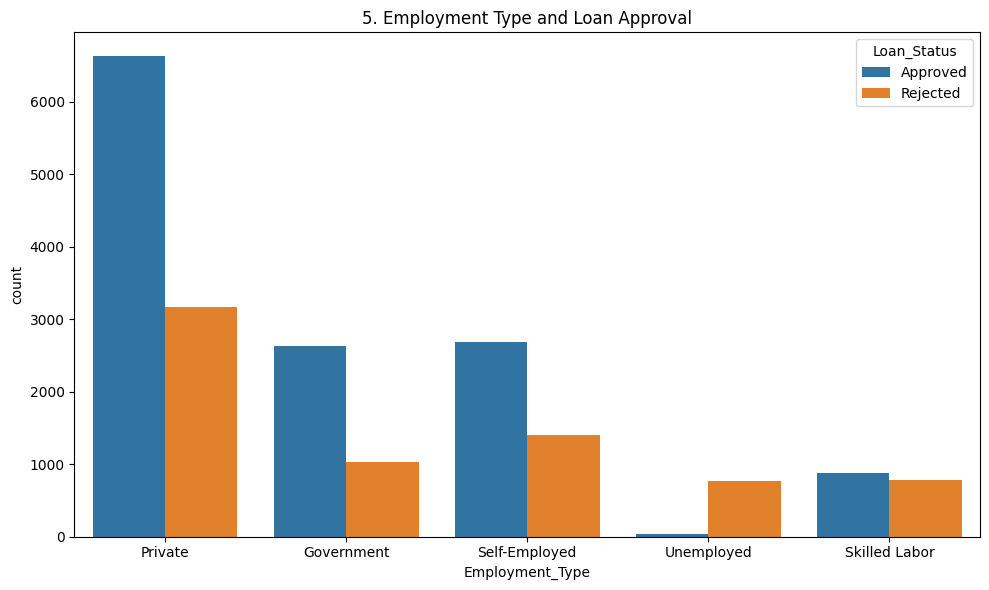

In [18]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Employment_Type', hue='Loan_Status')
plt.title(f'{plot_no}. Employment Type and Loan Approval')
show_fig()
plot_no += 1

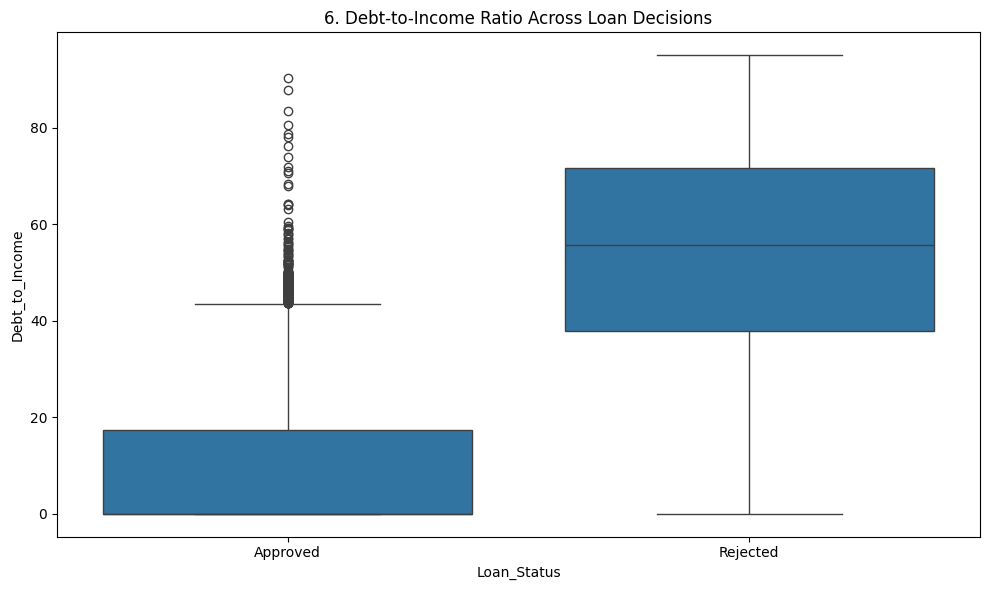

In [19]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Loan_Status', y='Debt_to_Income')
plt.title(f'{plot_no}. Debt-to-Income Ratio Across Loan Decisions')
show_fig()
plot_no += 1

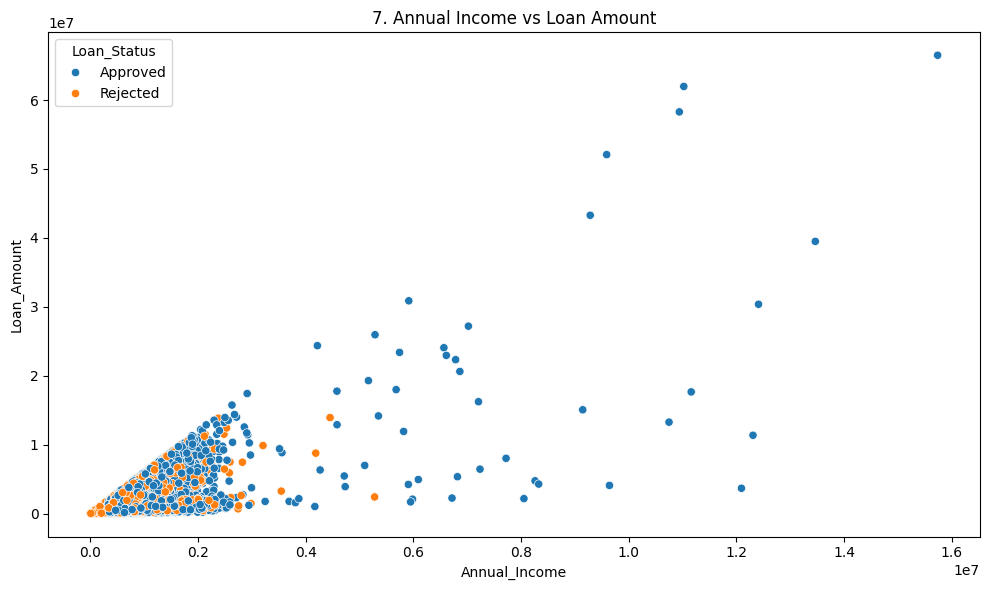

In [20]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Annual_Income', y='Loan_Amount', hue='Loan_Status')
plt.title(f'{plot_no}. Annual Income vs Loan Amount')
show_fig()
plot_no += 1

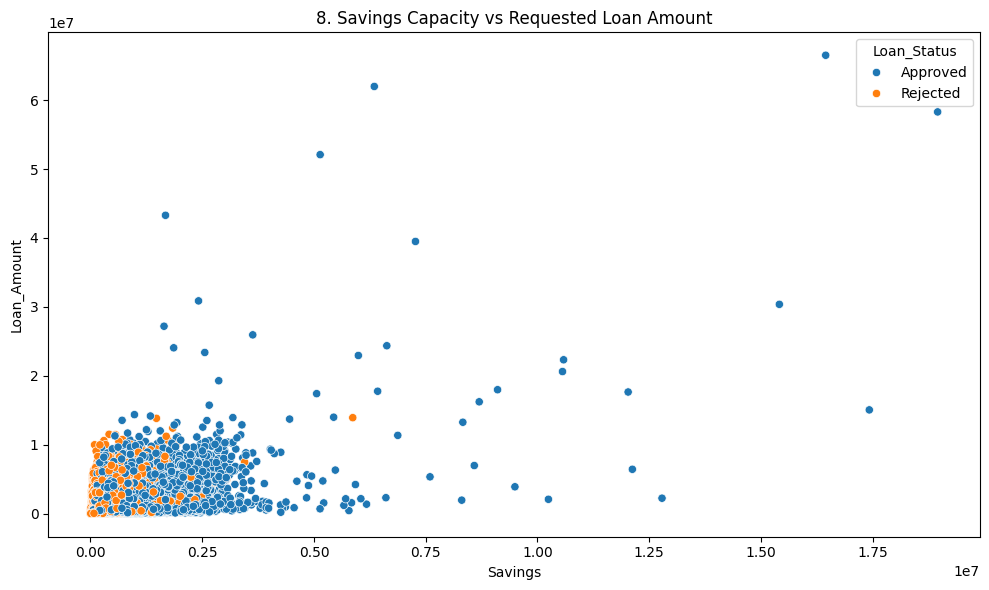

In [21]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Savings', y='Loan_Amount', hue='Loan_Status')
plt.title(f'{plot_no}. Savings Capacity vs Requested Loan Amount')
show_fig()
plot_no += 1

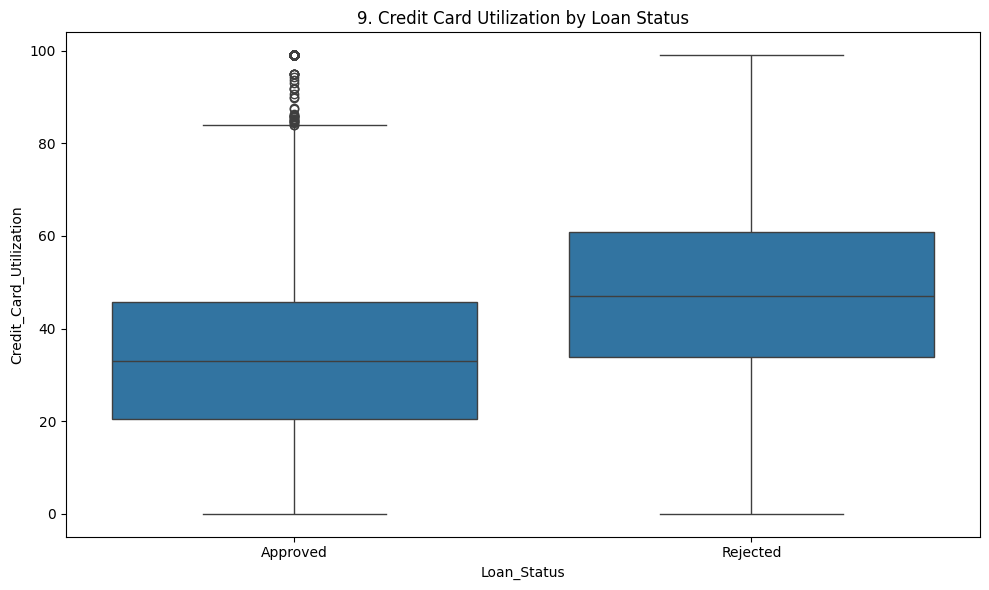

In [22]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Loan_Status', y='Credit_Card_Utilization')
plt.title(f'{plot_no}. Credit Card Utilization by Loan Status')
show_fig()
plot_no += 1

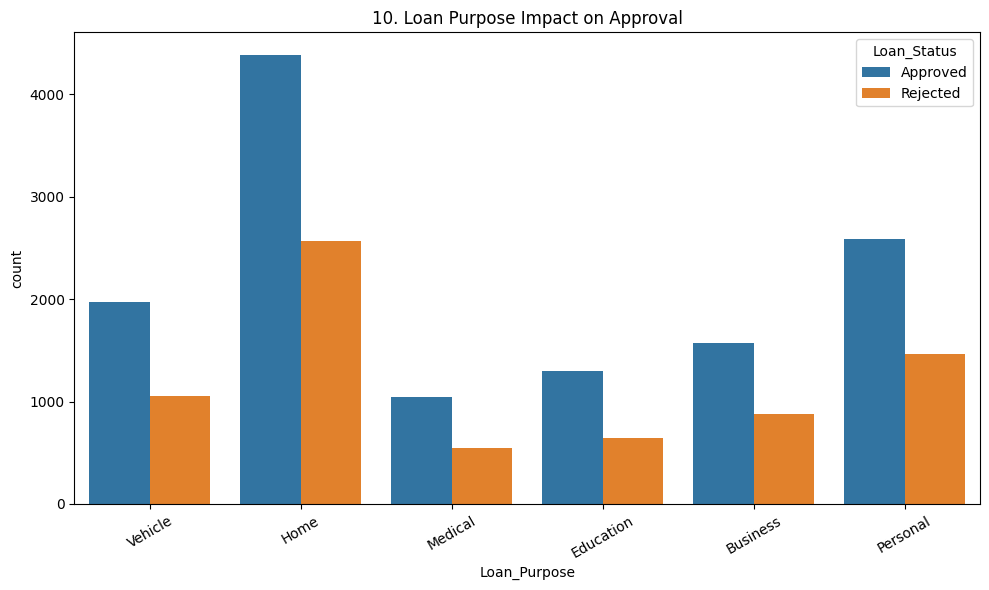

In [23]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Loan_Purpose', hue='Loan_Status')
plt.xticks(rotation=30)
plt.title(f'{plot_no}. Loan Purpose Impact on Approval')
show_fig()
plot_no += 1

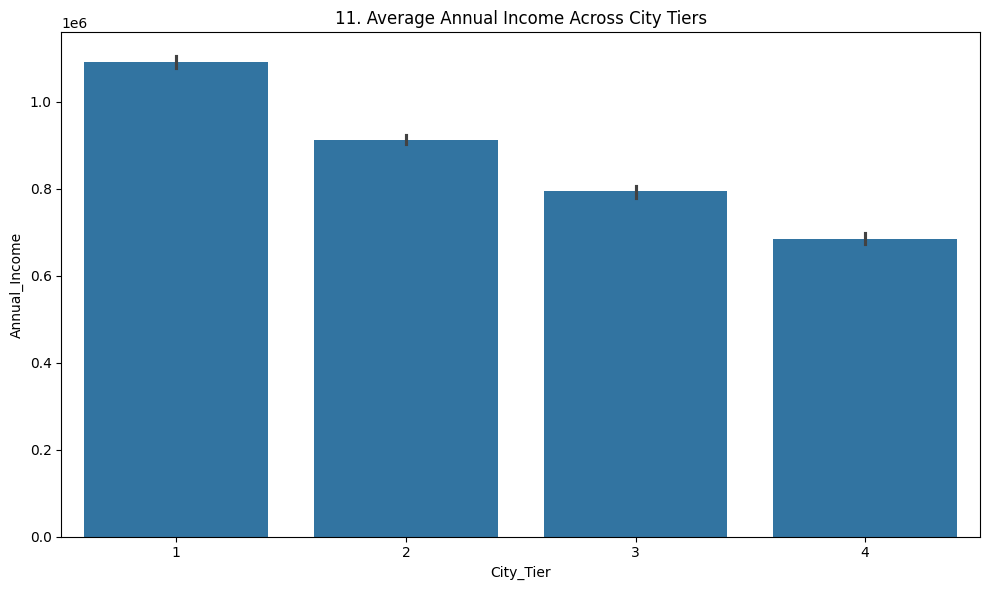

In [24]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='City_Tier', y='Annual_Income', estimator='mean')
plt.title(f'{plot_no}. Average Annual Income Across City Tiers')
show_fig()
plot_no += 1

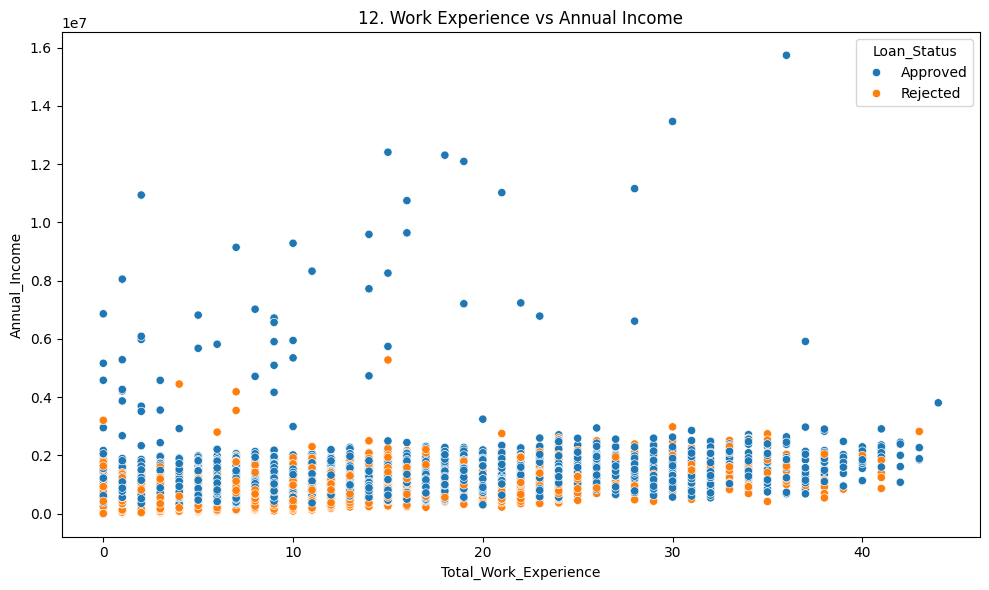

In [25]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Total_Work_Experience', y='Annual_Income', hue='Loan_Status')
plt.title(f'{plot_no}. Work Experience vs Annual Income')
show_fig()
plot_no += 1

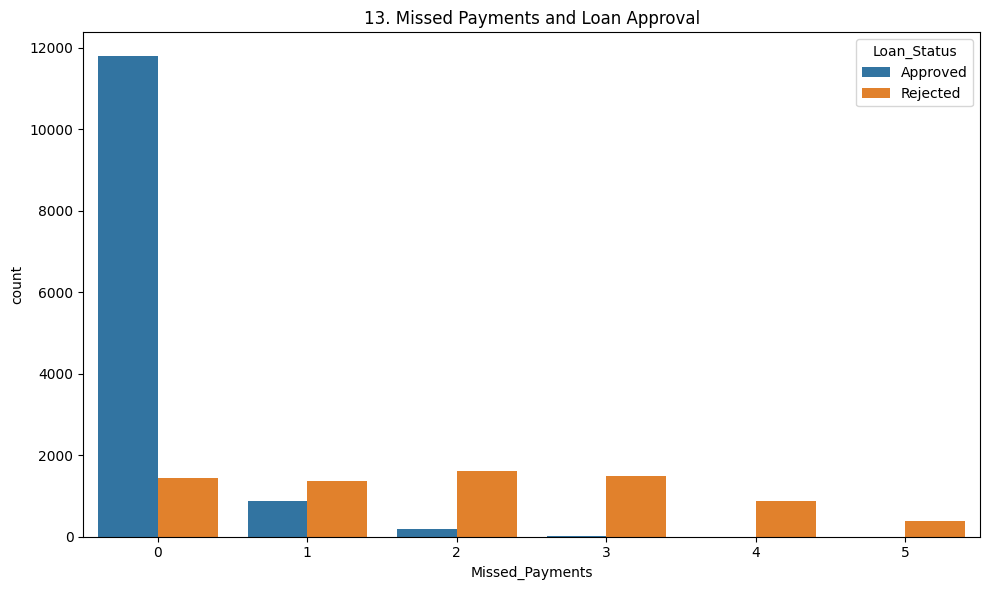

In [26]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Missed_Payments', hue='Loan_Status')
plt.title(f'{plot_no}. Missed Payments and Loan Approval')
show_fig()
plot_no += 1

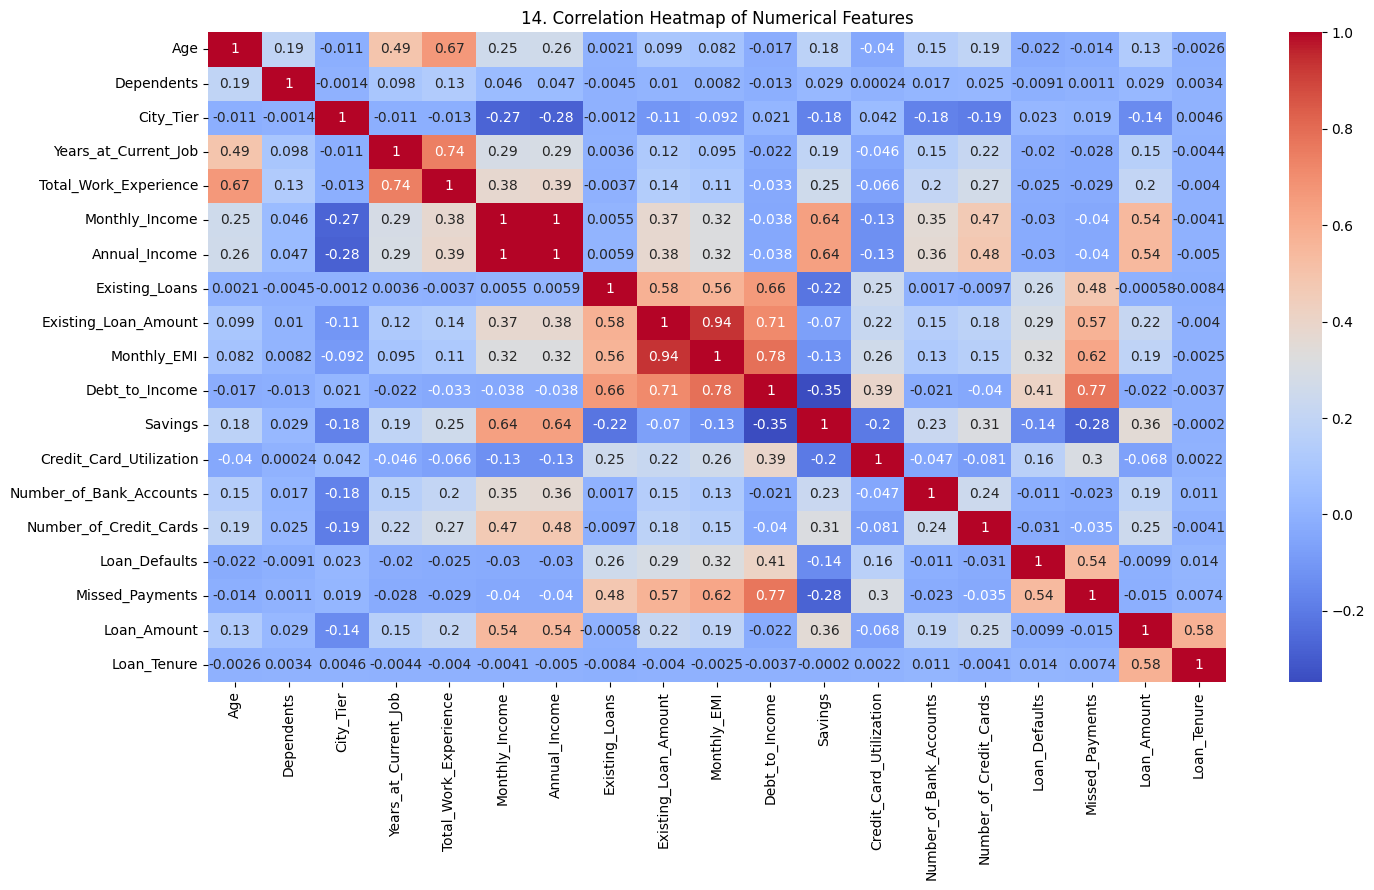

In [27]:
corr = df.select_dtypes(include='number').corr()

fig = plt.figure(figsize=(15, 9))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title(f'{plot_no}. Correlation Heatmap of Numerical Features')
show_fig()
plot_no += 1

# Model Training

## Create a copy of dataset

In [28]:
data = df.copy()

## Encode categorical columns

In [29]:
le = LabelEncoder()
for col in data.select_dtypes(include='object').columns:
    data[col] = le.fit_transform(data[col].astype(str))

## Separate features and target

In [30]:
X = data.drop('Loan_Status', axis=1)
y = data['Loan_Status']

## Split dataset into training and testing sets

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## Create pipeline with scaling and SVM classifier

In [32]:
model = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42))
])

## Train the model

In [33]:
model.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier', SVC(random_state=42))])

## Predict on test data

In [34]:
y_pred = model.predict(X_test)

## Print model accuracy

In [35]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy Score: {accuracy:.4f}")

Accuracy Score: 0.9365


## Plot confusion matrix

<Figure size 800x600 with 0 Axes>

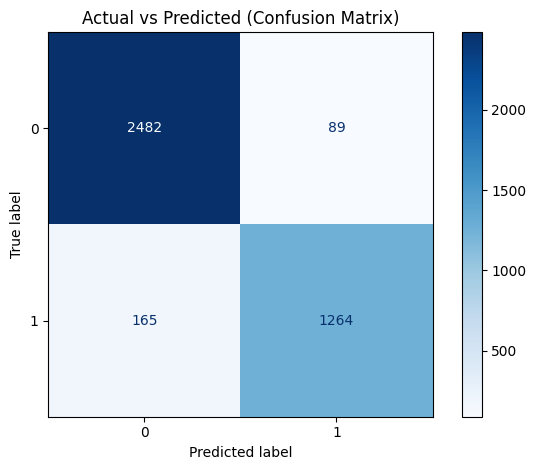

In [36]:
fig = plt.figure(figsize=(8,6))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap='Blues',
    values_format='d'
)
plt.title("Actual vs Predicted (Confusion Matrix)")
plt.tight_layout()
plt.show()